In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
train_data = pd.read_csv('test\Train_data.csv')

print(train_data.shape)

train_data.head(5)

FileNotFoundError: [Errno 2] No such file or directory: 'data\\data\\Train_data.csv'

In [ ]:
test_data2 = pd.read_csv('test/Test_data2.csv')
print(test_data2.shape)


test_data1 = pd.read_csv('test/Test_data1.csv')
print(test_data2.shape)


(3999, 31)
(3999, 31)


In [ ]:

def obvious_distribution(train_data):
    num_cols = train_data.shape[1]  

    fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 4 * num_cols))

    for i in range(num_cols):
        train_data_dimi = train_data.iloc[:, i]  
        axes[i].hist(train_data_dimi, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')  # 绘制直方图
        axes[i].grid(True)  # 添加网格
        axes[i].set_title(f"Feature {i+1} PDF (Histogram)")  # 设置子图标题
        axes[i].set_xlabel("Value")  # 设置 x 轴标签
        axes[i].set_ylabel("Density")  # 设置 y 轴标签

    plt.tight_layout()
    plt.show()

#obvious_distribution(test_data2)

### 对数据的观察
1. 数据近似满足多维高斯分布
2. 数据的每个维度之间数量级最大差了4个, 可能需要进行数据标准化
3. 数据是各向同性的
---

#### 在某个维度可视化高斯窗宽度大小对数据拟合的影响

可以直接使用我跑出来的图, 非常直观

### 结论

高斯窗宽度越宽, 数据越平滑, 也更偏离原本的数据分布.
高斯窗宽度越窄, 数据越接近原本的数据分布, 但是可能过拟合

根据其数学表达式:
$$
K(u) = \frac{1}{\sqrt{2\pi h^2}} \exp\left(-\frac{u^2}{2h^2}\right)
$$
也可以看出: 高斯窗宽度可以看作高斯核函数的方差, 宽度越宽, 方差越大, 分布越扁平. 也就是一个数据点对整体分布的影响更大

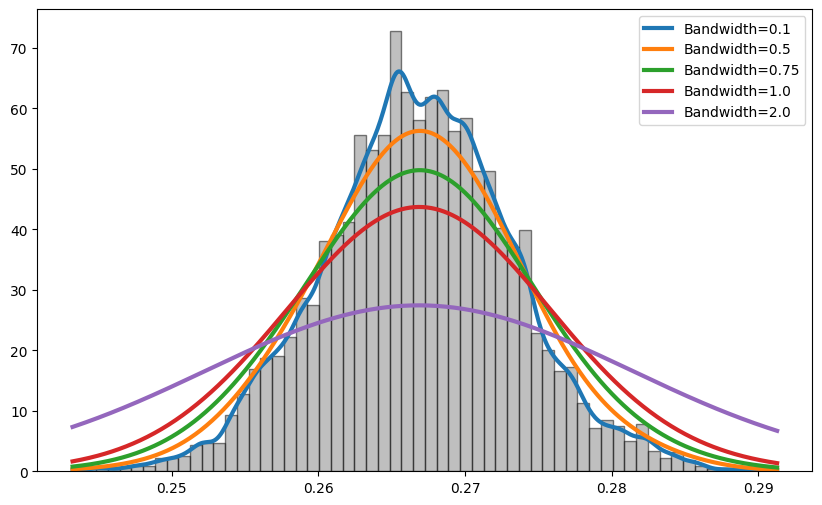

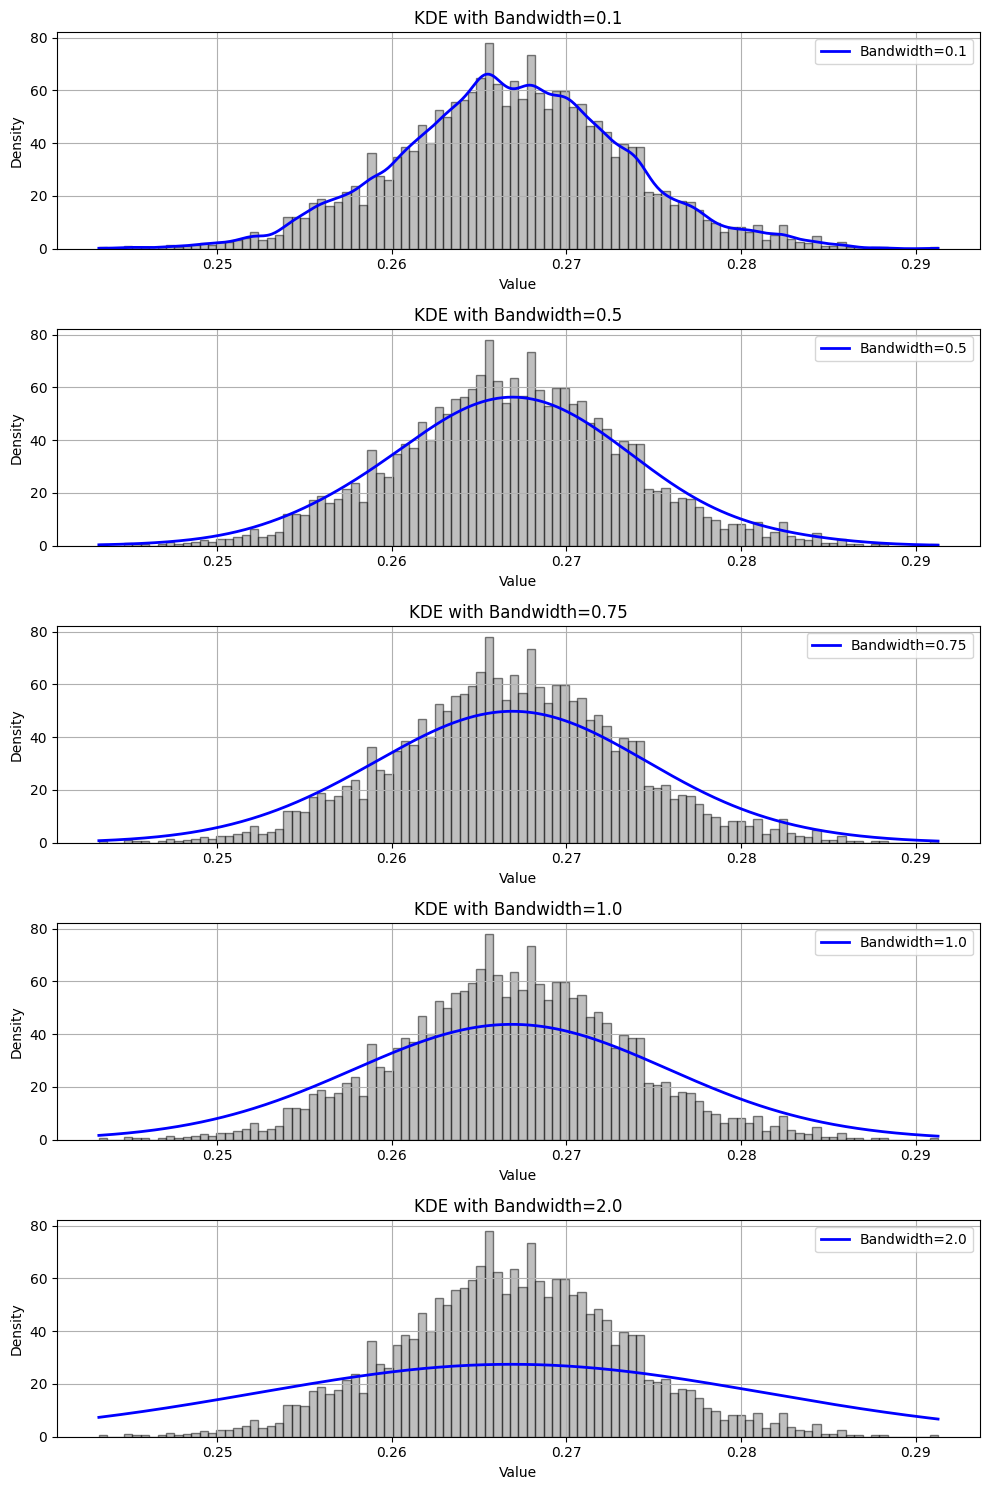

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# 维度1的数据
dimension_1_data = train_data.iloc[:, 0]  

bandwidths = [0.1, 0.5, 0.75, 1.0, 2.0]

plt.figure(figsize=(10,6))
plt.hist(dimension_1_data, bins=60, density=True, alpha=0.5, color='gray', edgecolor='black')
for bandwidth in bandwidths:
    kde = gaussian_kde(dimension_1_data, bw_method=bandwidth)
    # 生成 x 轴的点用于绘图
    x = np.linspace(dimension_1_data.min(), dimension_1_data.max(), 500)
    y = kde(x)  # 计算对应的概率密度
    plt.plot(x, y,linewidth=3, label=f"Bandwidth={bandwidth}")

plt.legend()
plt.show()

# 创建子图画布
fig, axes = plt.subplots(len(bandwidths), 1, figsize=(10, 3 * len(bandwidths)))

for i, bw in enumerate(bandwidths):
    kde = gaussian_kde(dimension_1_data, bw_method=bw)
    
    x = np.linspace(dimension_1_data.min(), dimension_1_data.max(), 500)
    y = kde(x)  # 计算对应的概率密度
    
    # 在子图中绘制 KDE 曲线
    axes[i].plot(x, y, label=f"Bandwidth={bw}", color='blue', linewidth=2)
    axes[i].hist(dimension_1_data, bins=100, density=True, alpha=0.5, color='gray', edgecolor='black')  # 叠加直方图
    axes[i].grid(True)
    axes[i].set_title(f"KDE with Bandwidth={bw}")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].legend()

# 调整子图之间的间距
plt.tight_layout()

# 显示图像
plt.show()

### 使用核函数进行数据分析

1. 数据标准化, 并进行pca降维,初步打算降到五维
2. 核函数估计求出最终的5元高斯分布
3. 估计出这个高斯分布的均值和方差
4. 使用马氏距离评估是否是异常点
5. 可视化

In [ ]:
mu = train_data.mean(axis=0)
print(mu.shape)
cov = train_data.cov()
std = train_data.std(axis=0)
print(std.shape)
print(cov.shape)
standand_data = (train_data - mu) / std
standand_data.head()

(31,)
(31,)
(31, 31)


,0.271032874,3649.739415,4451.320791,9.22314238,32.39289976,47.55975363,2798.975799,64.99582452,122.8987964,0.197826456,...,92.26253071,62.8069839,53.28670886,26.66217256,60.48285399,24.22930091,37.20819813,46.4305264,35.86532151,12.93064205
0,0.845582,0.959610,2.152213,0.231087,-1.837054,1.074315,-0.512124,0.598390,0.533864,-1.281436,...,0.851226,-0.453638,0.357934,0.667908,-0.171308,-1.428009,0.089037,-0.046613,0.519688,2.109788
1,0.536821,0.250529,-0.174280,1.257498,-0.031146,-0.999929,0.358371,1.588304,-1.981940,-1.384925,...,0.512849,-0.485502,0.191879,0.684164,-0.969333,-1.308857,0.130907,-0.466507,-1.053883,1.400921
2,0.550116,-0.981376,-0.372720,0.003507,1.396939,-0.747270,-1.356071,0.679552,-0.951349,-1.115231,...,-1.734296,-0.452150,0.074765,0.688832,-0.513219,-1.288522,-0.631526,-1.939205,-1.566414,-1.518982
3,0.828003,0.943870,0.031466,-0.979088,0.326612,0.376469,-0.339783,-2.180865,0.518786,-1.294708,...,0.911752,-0.343411,0.043603,0.710665,0.066915,-1.418157,0.031506,-1.315594,0.637452,-0.297748
4,0.437810,0.297449,-0.325171,-0.267386,-1.260612,-0.674907,0.818291,-0.782771,1.754484,-1.242635,...,0.885289,-0.240559,0.018657,0.849854,-1.174883,-1.223231,-0.706684,-1.291362,-0.971263,-0.969787


In [ ]:
from sklearn.neighbors import KernelDensity

# 使用各向同性高斯核（带宽矩阵为标量）
kde = KernelDensity(kernel='gaussian', bandwidth=0.5)  
kde.fit(train_data)  # 拟合模型

# 计算测试集密度（对数概率）
log_density = kde.score_samples(test_data2)
density = np.exp(log_density)  # 转换为概率密度

# 输出前5个样本的密度
print("测试集前5个样本的密度:", density[:5])

测试集前5个样本的密度: [2.28134256e-07 2.28162817e-07 2.28134256e-07 2.28142538e-07
 2.28134309e-07]


In [ ]:
# 设定密度阈值（如最低5%的密度为异常）
threshold = np.percentile(density, 10)
outliers = density < threshold

# 输出异常点索引
print("异常点数量:", sum(outliers))
print("异常点索引:", np.where(outliers)[0])

异常点数量: 400
异常点索引: [2004 2006 2010 2012 2024 2031 2044 2045 2051 2060 2067 2070 2072 2078
 2080 2090 2095 2103 2106 2110 2116 2120 2123 2131 2141 2142 2143 2153
 2158 2160 2161 2162 2165 2167 2172 2177 2184 2193 2194 2200 2201 2214
 2215 2226 2227 2231 2233 2255 2260 2268 2269 2276 2278 2280 2293 2295
 2297 2301 2307 2314 2324 2325 2326 2328 2330 2339 2342 2359 2379 2380
 2389 2390 2403 2405 2407 2415 2418 2419 2420 2421 2429 2430 2435 2437
 2438 2442 2450 2453 2454 2460 2462 2466 2469 2473 2480 2483 2486 2491
 2504 2514 2517 2526 2531 2535 2538 2539 2540 2541 2550 2552 2557 2558
 2561 2562 2563 2565 2566 2568 2571 2572 2575 2578 2580 2583 2585 2587
 2597 2601 2603 2605 2606 2615 2618 2629 2631 2636 2639 2640 2651 2655
 2656 2657 2670 2672 2676 2683 2685 2687 2699 2701 2707 2709 2711 2715
 2717 2724 2732 2734 2737 2738 2743 2745 2750 2753 2762 2787 2790 2793
 2794 2796 2797 2798 2806 2807 2813 2814 2825 2832 2833 2836 2841 2848
 2852 2861 2882 2888 2891 2895 2907 2908 2909 2911 2916 291

In [ ]:
import matplotlib.pyplot as plt

# 取前两个维度可视化
x = train_data[:, 0]
y = train_data[:, 1]

# 生成网格点
x_grid, y_grid = np.meshgrid(np.linspace(x.min(), x.max(), 100),
                             np.linspace(y.min(), y.max(), 100))
grid_points = np.column_stack([x_grid.ravel(), y_grid.ravel(), np.zeros((10000, 3))])  # 仅用前两维

# 计算网格点密度（仅展示前两维）
log_density_grid = kde.score_samples(grid_points[:, :2])
density_grid = np.exp(log_density_grid).reshape(x_grid.shape)

# 绘制密度等高线
plt.figure(figsize=(10, 6))
plt.scatter(x, y, c='blue', s=5, alpha=0.5, label='正常点')
plt.contour(x_grid, y_grid, density_grid, levels=10, cmap='viridis')
plt.colorbar(label='概率密度')
plt.xlabel('PCA维度1'), plt.ylabel('PCA维度2')
plt.title('多元高斯核密度估计')
plt.legend()
plt.show()

InvalidIndexError: (slice(None, None, None), 0)


### **递归核密度估计（Recursive Kernel Density Estimation）**

#### **1. 基本思想**
传统的核密度估计需要一次性处理所有数据点，而**递归核密度估计**是一种增量式方法，能够逐步更新密度估计，适用于实时数据流或在线学习场景。其核心是动态调整历史估计与新数据的权重，避免重新计算全量数据。

#### **2. 数学形式**
假设已有前 \( t-1 \) 个数据的密度估计 \( $\hat{f}_{t-1}(x)$ \)，当第 \( t \) 个新数据点 \( x_t \) 到达时，递归更新公式为：
$$
\hat{f}_t(x) = \alpha \cdot \hat{f}_{t-1}(x) + (1-\alpha) \cdot K(x - x_t)
$$
• **\( \alpha \)**：遗忘因子（\( 0 < \alpha < 1 \)），控制历史估计的衰减速度。  
  • \( \alpha \) 越大，历史数据权重越高，对新数据不敏感；  
  • \( \alpha \) 越小，模型对新数据响应更快，但可能受噪声影响更大。

